# Week 9 Phase 1.14 — M3-margin active acquisition

This teaching notebook reads published artifacts; it does not rerun the sequential GP experiment.

## 1. What Phase 1.13 proved—and did not prove

Phase 1.13 established that M3 was a stronger **predictive model** on the same frozen A0 labels. It did not establish that M3 chooses better labels.

In [1]:
from pathlib import Path
import json, pandas as pd
from IPython.display import display, Image, Markdown
ROOT=Path.cwd().parents[1] if Path.cwd().name=='week_09' else Path.cwd()
OUT=ROOT/'outputs'/'week9_phase1_14_m3_margin_acquisition'
display(json.loads((OUT/'baseline_gate.json').read_text()))

{'A0_paths': 100,
 'P0_q20_AULC': 0.8424908088235293,
 'conduction': 332,
 'current_head': 'fbe76352f86580818659ab87fa23ec29a74c7f59',
 'exact_branch_base': 'fbe76352f86580818659ab87fa23ec29a74c7f59',
 'folds_per_repeat': 5,
 'historical_changes': [],
 'initial_design_matches': 100,
 'keyholes': 73,
 'outer_runs': 100,
 'phase113_decision': 'HYBRID_GAIN_SUPPORTED',
 'phase113_parent_sha': 'fbe76352f86580818659ab87fa23ec29a74c7f59',
 'population': 405,
 'repeat_blocks': 20,
 'status': 'PASS'}

## 2. The clean test

P0 and P1 both use M3. P0 receives A0 labels; P1 sequentially selects its own labels. Therefore P1−P0 isolates the path contribution for this evaluator.

In [2]:
display(json.loads((OUT/'protocol_reconstruction.json').read_text())); display(json.loads((OUT/'acquisition_specification.json').read_text()))

{'A0_complete_paths': 100,
 'A0_source': 'Phase 1.8 exact query_paths.csv.gz reconstructed from Week 8.5 checkpoints',
 'budget_semantics': {'grid': [16,
   17,
   18,
   19,
   20,
   21,
   22,
   23,
   24,
   25,
   26,
   27,
   28,
   29,
   30,
   31,
   32,
   33,
   34,
   35,
   36,
   37,
   38,
   39,
   40,
   41,
   42,
   43,
   44,
   45,
   46,
   47,
   48,
   49,
   50,
   51,
   52,
   53,
   54,
   55,
   56,
   57,
   58,
   59,
   60,
   61,
   62,
   63,
   64,
   65,
   66,
   67,
   68,
   69,
   70,
   71,
   72,
   73,
   74,
   75,
   76,
   77,
   78,
   79,
   80],
  'one_query_per_step': True,
  'order': 'fit and evaluate at budget B; if B<80, select the point revealed for B+1'},
 'candidate_eligibility': 'outer training pool minus currently queried indices',
 'differences_from_prompt': [],
 'evaluation_only': ['B1', 'q20', 'q30', 'held-out labels'],
 'fit_seed': 'Phase 1.13 shared_physics seed keyed by run_id and budget',
 'initial_design': {'matched_A0

{'acquisition': {'batch_size': 1,
  'lookahead': False,
  'orientation': 'maximum',
  'score': '1 - 2*abs(p-0.5)',
  'tie_break': 'smallest population row index'},
 'decision_safeguards': {'acquisition_numeric_instability': 'sensitivity median B80 Jaccard <0.25 together with absolute mean q20 AULC change >=0.01, or sensitivity optimizer convergence <0.80',
  'clear_gain': 'paired 95% interval strictly above zero',
  'early_or_late_gain': 'region interval above zero while the other region is not clearly below zero',
  'severe_global_degradation': 'at B40 or B80, mean P1-P0 full81 accuracy <= -0.02 or Keyhole recall <= -0.05'},
 'endpoints': {'early': 'B16-B40',
  'late': 'B41-B80',
  'primary': 'Fold-B1-q20 accuracy normalized trapezoidal AULC B16-B80',
  'secondary_q30': 'Fold-B1-q30 accuracy AULC B16-B80',
  'thresholds': [0.8, 0.82, 0.84]},
 'inference': {'bootstrap_draws': 10000,
  'unit': '20 paired repeat blocks; five folds retained together'},
 'model': {'length_bounds': [0.01, 1

## 3. Main q20 learning curves and paired path contrast

,model,subset,budget,mean_accuracy,ci_lower,ci_upper
0,P0,B1_q20,16,0.785882,0.768235,0.802941
1,P0,B1_q20,17,0.802941,0.789397,0.816471
2,P0,B1_q20,18,0.805882,0.790000,0.818235
3,P0,B1_q20,19,0.810588,0.796471,0.822941
4,P0,B1_q20,20,0.814118,0.800000,0.825882
...,...,...,...,...,...,...
190,P1,B1_q20,76,0.861765,0.855294,0.867647
191,P1,B1_q20,77,0.863529,0.857647,0.869412
192,P1,B1_q20,78,0.862941,0.857059,0.868824
193,P1,B1_q20,79,0.861765,0.855294,0.867647


,contrast,subset,mean_difference,ci_lower,ci_upper,positive_repeat_blocks,zero_repeat_blocks,negative_repeat_blocks,bootstrap_draws,comparison
0,P1-P0,B1_q20,0.002132,-0.001167,0.005621,12,0,8,10000,same M3 evaluator; path only
1,P1-P0,B1_q30,0.003587,0.001194,0.006091,16,0,4,10000,same M3 evaluator; path only


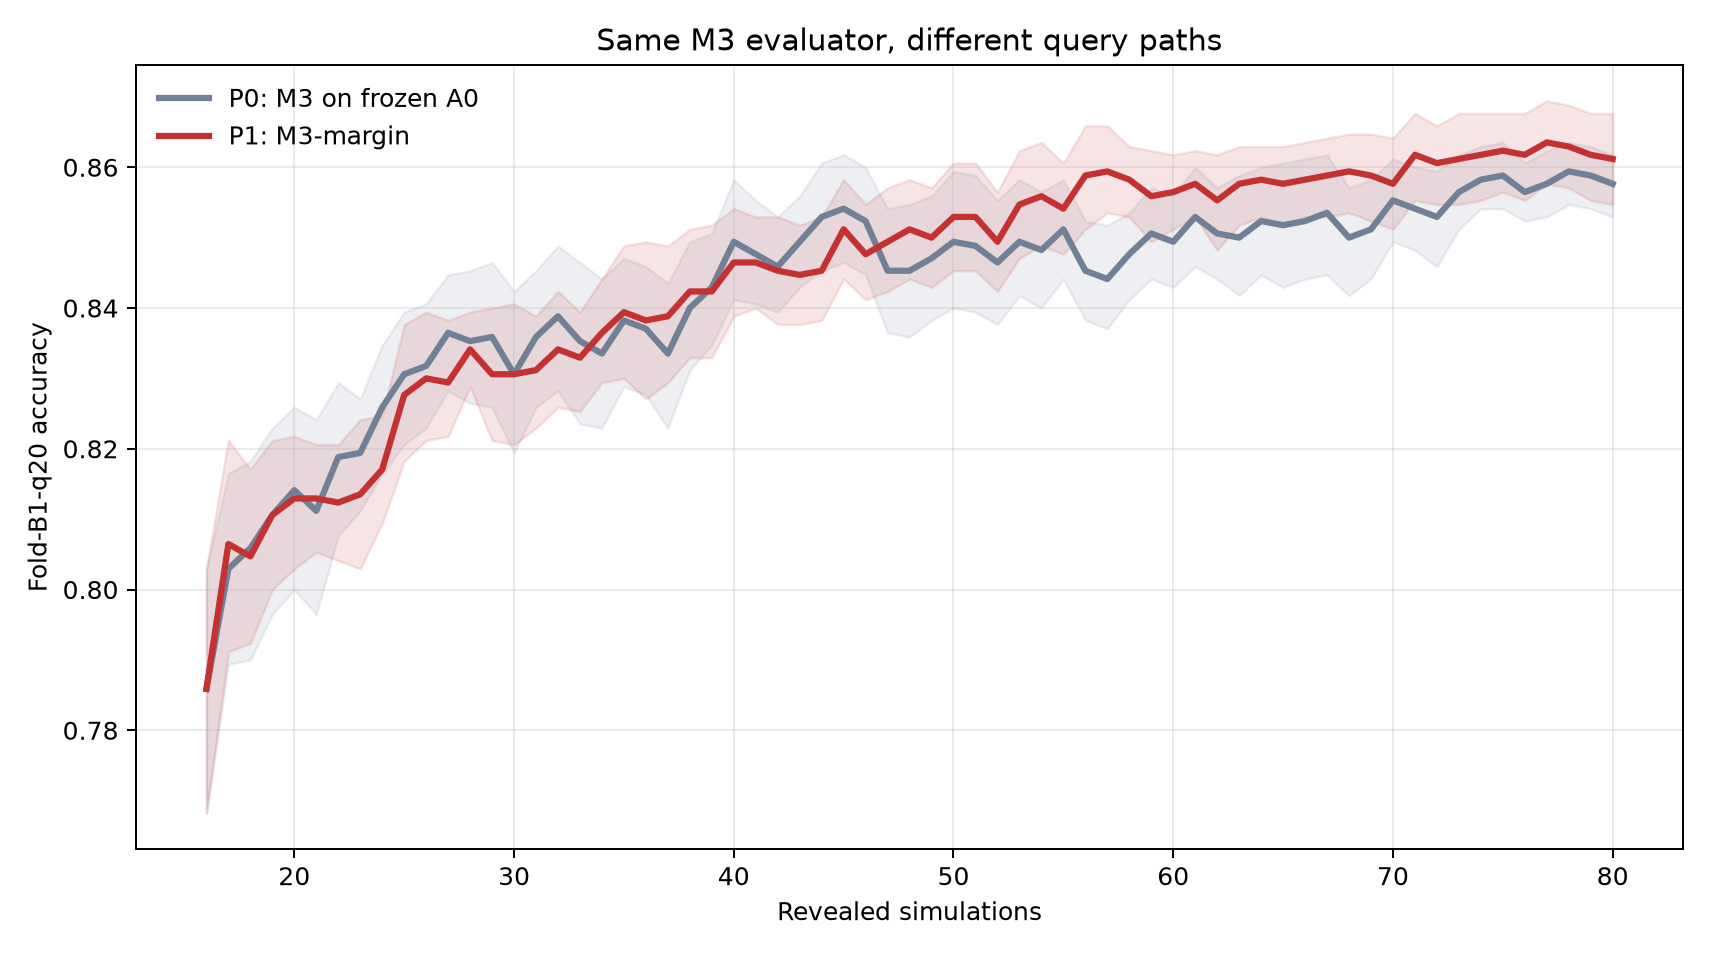

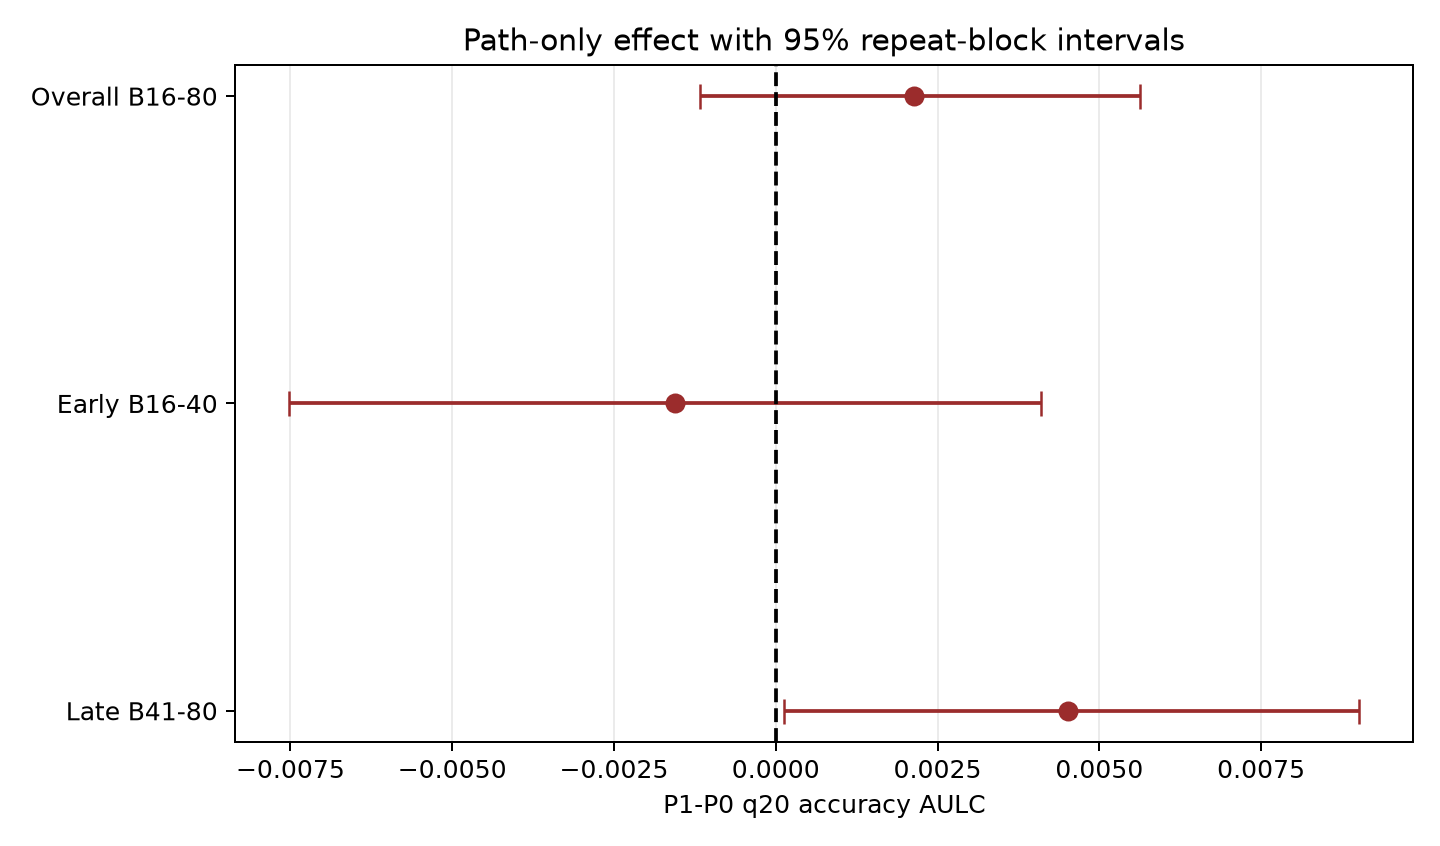

In [3]:
display(pd.read_csv(OUT/'learning_curve_summary.csv').query("subset=='B1_q20'")); display(pd.read_csv(OUT/'paired_contrasts.csv')); display(Image(filename=str(OUT/'figures'/'01_q20_learning_curves.png'))); display(Image(filename=str(OUT/'figures'/'02_primary_early_late_contrasts.png')))

## 4. Early/late behavior and checkpoints

The regions B16–40 and B41–80 were fixed before results.

In [4]:
display(pd.read_csv(OUT/'early_late_summary.csv')); display(pd.read_csv(OUT/'early_late_contrasts.csv')); display(pd.read_csv(OUT/'checkpoint16_40_80_summary.csv'))

,model,region,mean_AULC,ci_lower,ci_upper
0,P0,EARLY_B16_40,0.827598,0.822010,0.833333
1,P0,LATE_B41_80,0.851501,0.846169,0.856923
2,P1,EARLY_B16_40,0.826042,0.821617,0.830601
3,P1,LATE_B41_80,0.856011,0.850739,0.860890


,contrast,region,mean_difference,ci_lower,ci_upper,positive_repeat_blocks,zero_repeat_blocks,negative_repeat_blocks,bootstrap_draws
0,P1-P0,EARLY_B16_40,-0.001556,-0.007525,0.004106,11,0,9,10000
1,P1-P0,LATE_B41_80,0.004510,0.000120,0.009020,11,0,9,10000


,model,contrast,subset,budget,metric,mean,ci_lower,ci_upper
0,P0,none,B1_q20,16,accuracy,0.785882,0.768235,0.803529
1,P1,none,B1_q20,16,accuracy,0.785882,0.768824,0.802941
2,difference,P1-P0,B1_q20,16,accuracy,0.000000,0.000000,0.000000
3,P0,none,B1_q20,16,balanced_accuracy,0.771914,0.751435,0.790494
4,P1,none,B1_q20,16,balanced_accuracy,0.771914,0.750929,0.790229
5,difference,P1-P0,B1_q20,16,balanced_accuracy,0.000000,0.000000,0.000000
6,P0,none,B1_q20,16,keyhole_recall,0.722119,0.666511,0.773190
7,P1,none,B1_q20,16,keyhole_recall,0.722119,0.666135,0.773354
8,difference,P1-P0,B1_q20,16,keyhole_recall,0.000000,0.000000,0.000000
9,P0,none,B1_q20,16,conduction_recall,0.821709,0.787273,0.856572


## 5. Sample-efficiency thresholds

First-hit budgets are right-censored. Non-crossings are never assigned a favorable artificial budget.

,unit,model,threshold,n_units,reached_count,reached_fraction,censored_count,median_first_hit_budget_reached_only,q1_first_hit_budget_reached_only,q3_first_hit_budget_reached_only,missing_crossings_not_imputed
0,outer_run,P0,0.80,100,94,0.94,6,16.0,16.0,20.00,True
1,outer_run,P0,0.82,100,94,0.94,6,16.0,16.0,20.00,True
2,outer_run,P0,0.84,100,77,0.77,23,18.0,16.0,26.00,True
3,outer_run,P1,0.80,100,95,0.95,5,16.0,16.0,18.00,True
4,outer_run,P1,0.82,100,95,0.95,5,16.0,16.0,18.00,True
5,outer_run,P1,0.84,100,79,0.79,21,18.0,16.0,25.00,True
6,repeat,P0,0.80,20,20,1.00,0,17.0,16.0,18.00,True
7,repeat,P0,0.82,20,20,1.00,0,18.0,17.0,20.25,True
8,repeat,P0,0.84,20,20,1.00,0,23.5,20.0,26.00,True
9,repeat,P1,0.80,20,20,1.00,0,17.0,16.0,18.00,True


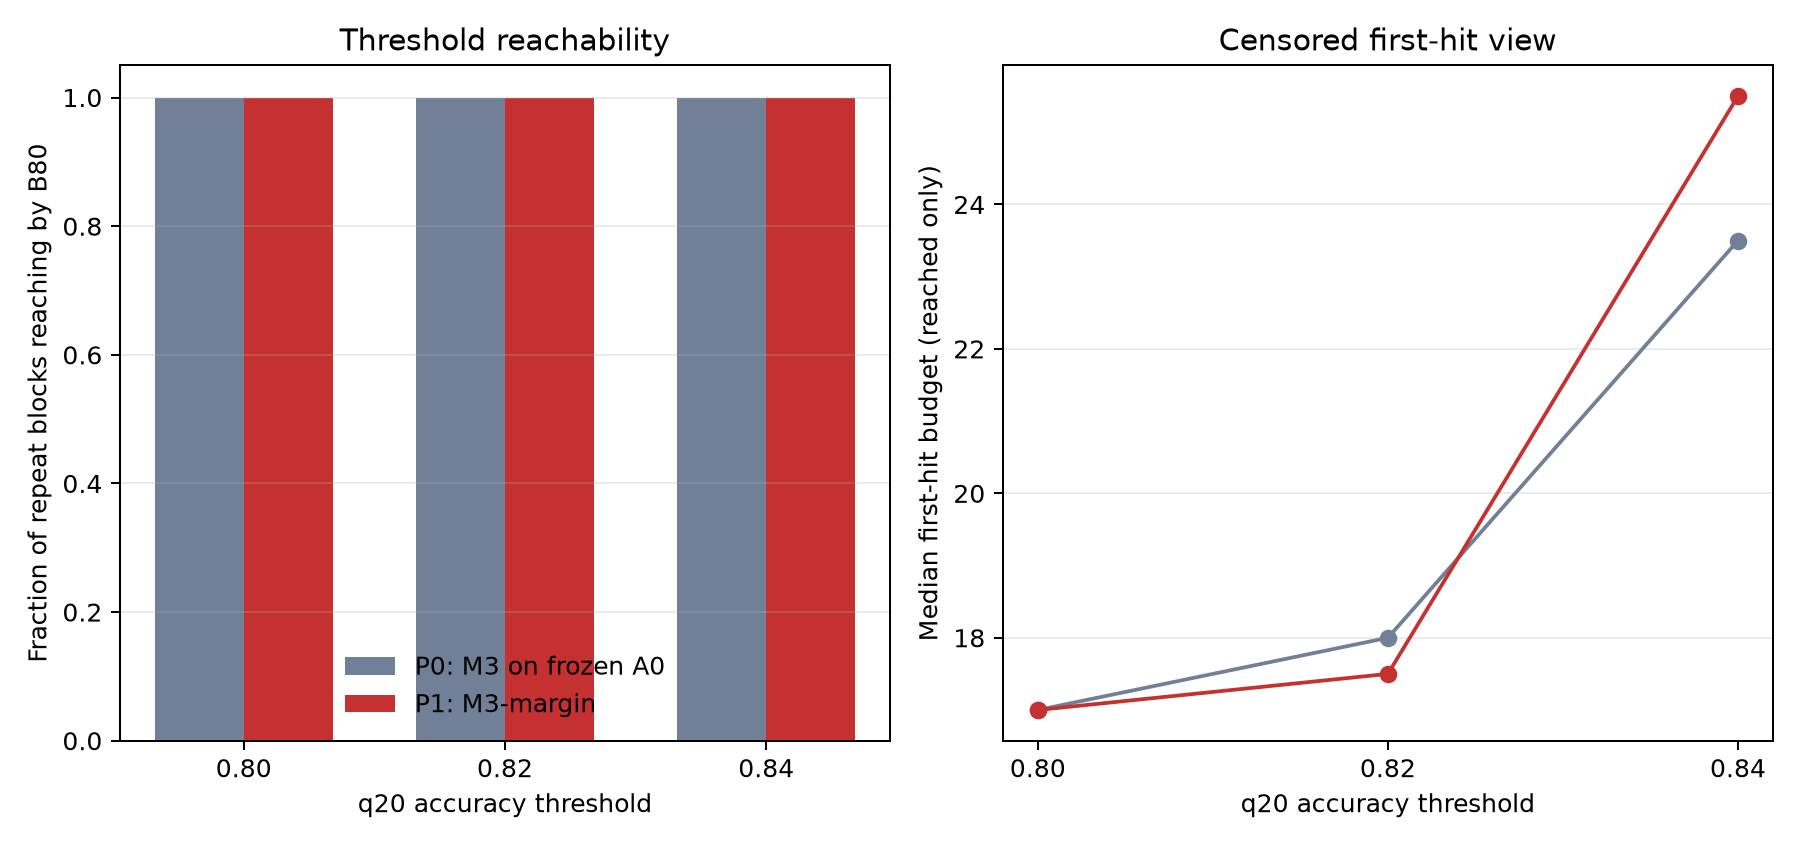

In [5]:
display(pd.read_csv(OUT/'sample_efficiency_thresholds.csv')); display(Image(filename=str(OUT/'figures'/'03_sample_efficiency_thresholds.png')))

## 6. What M3 queries and how paths diverge

All B1 distances and labels in these tables are retrospective diagnostics only.

,metric,mean,median,q1,q3,minimum,maximum,n
0,first_divergence_budget,17.040000,17.000000,17.000000,17.000000,17.000000,18.000000,100
1,shared_B40,29.620000,30.000000,28.000000,31.000000,21.000000,36.000000,100
2,jaccard_B40,0.591644,0.600000,0.538462,0.632653,0.355932,0.818182,100
3,unique_P0_B40,10.380000,10.000000,9.000000,12.000000,4.000000,19.000000,100
4,unique_P1_B40,10.380000,10.000000,9.000000,12.000000,4.000000,19.000000,100
5,shared_B80,66.020000,66.000000,63.000000,69.000000,48.000000,74.000000,100
6,jaccard_B80,0.705546,0.702128,0.649485,0.758242,0.428571,0.860465,100
7,unique_P0_B80,13.980000,14.000000,11.000000,17.000000,6.000000,32.000000,100
8,unique_P1_B80,13.980000,14.000000,11.000000,17.000000,6.000000,32.000000,100


,path,metric,mean,median,q1,q3,n
0,P0,truth,3.732813e-01,0.000000e+00,0.000000e+00,1.000000e+00,6400
1,P0,P,2.416047e+02,2.293845e+02,1.606056e+02,3.269310e+02,6400
2,P0,VX,5.380621e-01,5.207109e-01,3.000606e-01,7.468569e-01,6400
3,P0,LS,5.340189e-05,4.892181e-05,4.500000e-05,5.921217e-05,6400
4,P0,ST,3.443345e+02,3.407744e+02,3.094758e+02,3.757839e+02,6400
5,P0,h,8.926984e+08,8.491395e+08,6.856293e+08,1.037910e+09,6400
6,P0,B1_distance_posthoc,8.501286e-01,8.085445e-01,6.187742e-01,1.038998e+00,6400
7,P0,probability_before_reveal,NaN,NaN,NaN,NaN,0
8,P0,margin_abs_probability_minus_half,NaN,NaN,NaN,NaN,0
9,P1,truth,4.204688e-01,0.000000e+00,0.000000e+00,1.000000e+00,6400


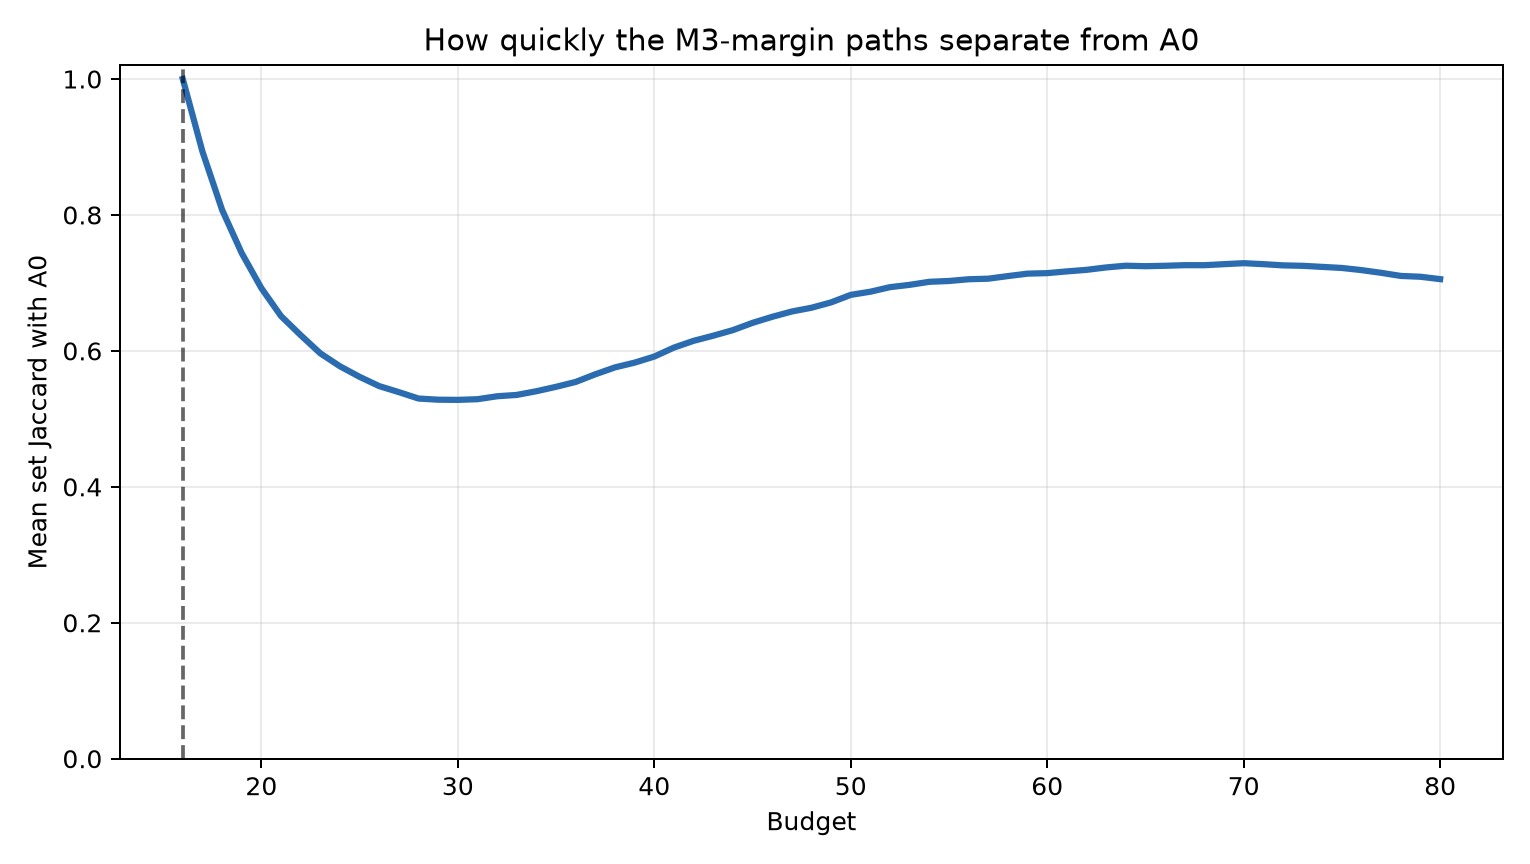

In [6]:
display(pd.read_csv(OUT/'path_overlap_summary.csv')); display(pd.read_csv(OUT/'query_characteristics.csv')); display(Image(filename=str(OUT/'figures'/'04_path_overlap.png')))

## 7. q30 and global full81 robustness

In [7]:
display(pd.read_csv(OUT/'paired_contrasts.csv').query("subset=='B1_q30'")); display(pd.read_csv(OUT/'full81_checkpoint_summary.csv'))

,contrast,subset,mean_difference,ci_lower,ci_upper,positive_repeat_blocks,zero_repeat_blocks,negative_repeat_blocks,bootstrap_draws,comparison
1,P1-P0,B1_q30,0.003587,0.001194,0.006091,16,0,4,10000,same M3 evaluator; path only


,model,contrast,subset,budget,metric,mean,ci_lower,ci_upper
0,P0,none,full81,16,roc_auc,0.980934,0.972927,0.986738
1,P1,none,full81,16,roc_auc,0.980934,0.972881,0.986658
2,difference,P1-P0,full81,16,roc_auc,0.000000,0.000000,0.000000
3,P0,none,full81,16,pr_auc,0.936580,0.923435,0.947389
4,P1,none,full81,16,pr_auc,0.936580,0.923283,0.947339
...,...,...,...,...,...,...,...,...
58,P1,none,full81,80,conduction_recall,0.989163,0.988091,0.990075
59,difference,P1-P0,full81,80,conduction_recall,0.000301,-0.001058,0.001504
60,P0,none,full81,80,brier_score,0.027362,0.026862,0.027852
61,P1,none,full81,80,brier_score,0.026332,0.025843,0.026823


## 8. Fit behavior and active-path upper-bound sensitivity

ARD lengths are standardized-space diagnostics, not physical importance.

,model,scope,metric,mean,median,q1,q3,n
0,P0,all_B16_80,residual_sd,0.810778,0.979099,0.709376,1.000000,6500
1,P0,all_B16_80,residual_sd_lower_bound_hit,0.074154,0.000000,0.000000,0.000000,6500
2,P0,all_B16_80,residual_sd_upper_bound_hit,0.478769,0.000000,0.000000,1.000000,6500
3,P0,all_B16_80,residual_sd_any_bound_hit,0.552923,1.000000,0.000000,1.000000,6500
4,P0,all_B16_80,any_length_lower_bound_hit,0.041846,0.000000,0.000000,0.000000,6500
...,...,...,...,...,...,...,...,...
99,P1,B80,anisotropy_ratio,149.588302,172.065163,88.234515,199.666975,100
100,P1,B80,l_P,26.865098,1.871797,1.131763,71.302153,100
101,P1,B80,l_VX,0.531817,0.527557,0.485568,0.590190,100
102,P1,B80,l_LS,54.529207,54.800018,3.421538,100.000000,100


,section,metric,mean,median,q1,q3,n
0,path_and_prediction,first_divergence_budget,38.250000,32.000000,22.750000,49.000000,16
1,path_and_prediction,selected_query_disagreement_fraction,0.326562,0.296875,0.046875,0.562500,20
2,path_and_prediction,jaccard_B40,0.913916,1.000000,0.893688,1.000000,20
3,path_and_prediction,jaccard_B80,0.983272,1.000000,0.993827,1.000000,20
4,path_and_prediction,L100_q20_AULC,0.841820,0.854090,0.818244,0.883502,20
5,path_and_prediction,L1000_q20_AULC,0.842210,0.852711,0.821576,0.883502,20
6,path_and_prediction,delta_L1000_minus_L100_q20_AULC,0.000391,0.000000,-0.000230,0.000919,20
7,L100,residual_sd_upper_bound_hit,0.704615,1.000000,0.000000,1.000000,1300
8,L100,any_length_upper_bound_hit,0.780000,1.000000,1.000000,1.000000,1300
9,L100,optimizer_converged,0.951538,1.000000,1.000000,1.000000,1300


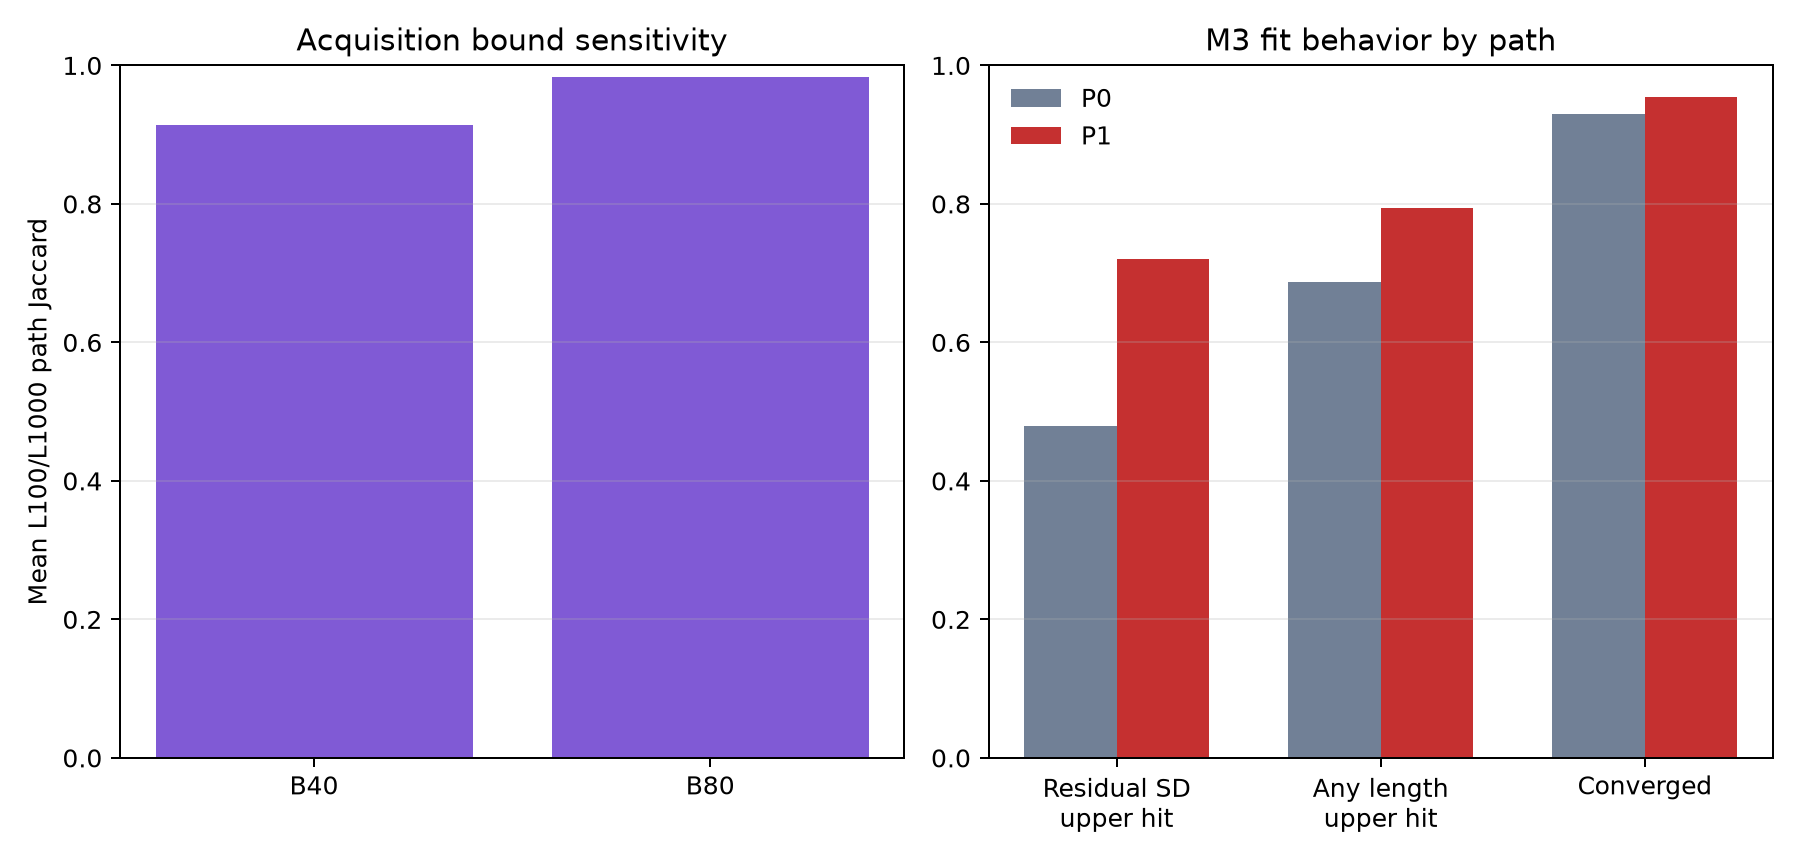

In [8]:
display(pd.read_csv(OUT/'m3_fit_bound_summary.csv')); display(pd.read_csv(OUT/'acquisition_bound_sensitivity_summary.csv')); display(Image(filename=str(OUT/'figures'/'05_acquisition_numeric_robustness.png')))

## 9. Safe conclusion

The evidence is a pool-based replay on one deterministic simulator dataset. It does not prove universal or theoretical acquisition superiority.

In [9]:
display(Markdown((OUT/'SUPERVISOR_PHASE1_14_ONE_PAGE.md').read_text()))

# Supervisor Phase 1.14 â€” one page

**Decision:** LATE_ACQUISITION_GAIN_ONLY

- Clean path-only q20 AULC: P0 0.8425, P1 0.8446, delta +0.0021 [-0.0012, +0.0056].
- Early delta -0.0016 [-0.0075, +0.0041]; late +0.0045 [+0.0001, +0.0090].
- B40/B80 q20 KH recall P0/P1: 0.772/0.749; 0.733/0.738.
- Median path Jaccard at B40/B80: 0.600/0.702; median first divergence B17.
- q30 delta: +0.0036 [+0.0012, +0.0061].
- L100/L1000 median B80 Jaccard: 1.000; q20 AULC sensitivity delta +0.0004.
- Novel physics/residual-aware acquisition follow-up: QUALIFIED; overall gain is unresolved despite a supported late-region effect.

Only the path changes in the primary comparison. No universal or theoretical active-learning claim is made.
